# Nepal Bank Stocks — Training Pipeline v4
### Changes from v3:
- Dropped 13 low/negative-importance features (keeps top 15 only)
- Trains **two** models: Direction Classifier + Return Regressor
- Saves all artifacts to `models/` for the inference pipeline
- Final walk-forward CV + test evaluation with full report

## 1 · Imports & Config

In [1]:
import os, json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, f1_score, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

BANK_PATH  = '../data/processed/combinedBankData.csv'
FX_PATH    = '../data/interim/NPR_USD.csv'
MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── PRUNED feature list based on v3 permutation importance ────────────────────
# Dropped (negative or near-zero AUC impact):
#   ret_lag2, ret_lag3, ret_lag5, ret_10d_lag1,   ← momentum lags hurt
#   rsi14_lag1, macd_hist_lag1,                   ← redundant with bb/stoch
#   close_to_ma63, cs_rank_lag1, policy_rate,     ← negative importance
#   vol_21, vol_5, dist_52w_high, npl             ← near-zero
FEATURE_COLS = [
    'close_to_ma21',    # #1 — price vs 21d MA (mean-reversion)
    'nepse_ret_lag1',   # #2 — yesterday's broad market return
    'month',            # #3 — seasonality
    'bb_pct_lag1',      # #4 — Bollinger band position
    'dist_52w_low',     # #5 — distance from 52-week low
    'ret_3d_lag1',      # #6 — 3-day cumulative return
    'stoch_k_lag1',     # #7 — stochastic oscillator
    'atr_ratio_lag1',   # #8 — normalised ATR (volatility)
    'vol_surge_lag1',   # #9 — volume spike
    'bank_enc',         # #10 — bank identity
    'nepse_bull',       # #11 — bull/bear regime flag
    'sector_ret_lag1',  # #12 — banking sector return yesterday
    'car',              # #13 — capital adequacy ratio
    'ret_lag1',         # #14 — yesterday's own return
    'vol_ratio_5_21',   # #15 — vol compression signal
]

MODEL_PARAMS = dict(
    max_iter=800, learning_rate=0.02, max_depth=4,
    min_samples_leaf=40, l2_regularization=2.0,
    max_bins=128, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=35,
    random_state=42
)

pd.set_option('display.float_format', '{:.5f}'.format)
print(f'Features : {len(FEATURE_COLS)}')
print(f'Models   : {MODELS_DIR}/')
print('Ready ✓')

Features : 15
Models   : models/
Ready ✓


## 2 · Load & Merge

In [2]:
bank = pd.read_csv(BANK_PATH, skipinitialspace=True)
bank.columns = bank.columns.str.strip()
bank['bank'] = bank['bank'].str.strip()
bank['date'] = pd.to_datetime(bank['date'])
bank = bank.sort_values(['bank', 'date']).reset_index(drop=True)

fx = pd.read_csv(FX_PATH)
fx.columns       = fx.columns.str.strip()
fx['date']       = pd.to_datetime(fx['Date'], format='%m/%d/%Y')
fx['npr_usd']    = fx['Price']
fx['fx_chg_pct'] = fx['Change %'].str.replace('%', '').astype(float)
fx = fx[['date', 'npr_usd', 'fx_chg_pct']].sort_values('date').reset_index(drop=True)

all_dates = pd.DataFrame({'date': pd.date_range(fx['date'].min(), bank['date'].max(), freq='D')})
fx_full   = all_dates.merge(fx, on='date', how='left').ffill().bfill()
df = bank.merge(fx_full, on='date', how='left')
pre_fx = df['date'] < fx['date'].min()
df.loc[pre_fx, ['npr_usd', 'fx_chg_pct']] = [fx['npr_usd'].iloc[0], 0.0]

print(f'Bank : {bank.shape}  |  {bank["bank"].nunique()} banks  |  '
      f'{bank["date"].min().date()} → {bank["date"].max().date()}')
print(f'Merged: {df.shape}')

Bank : (50141, 17)  |  17 banks  |  2011-11-13 → 2025-10-19
Merged: (50141, 19)


## 3 · Feature Engineering

In [3]:
# Cross-sectional (computed before per-bank loop)
df['ret_raw']  = df.groupby('bank')['close'].pct_change()
sector_ret     = df.groupby('date')['ret_raw'].mean().rename('sector_ret').reset_index()
df             = df.merge(sector_ret, on='date', how='left')

le = LabelEncoder()
le.fit(sorted(df['bank'].unique()))

# Save bank list (needed at inference time)
BANK_CLASSES = le.classes_.tolist()

chunks = []
for bank_name, grp in df.groupby('bank'):
    g = grp.sort_values('date').copy()
    c = g['close']
    ret = c.pct_change()

    # Momentum
    g['ret_lag1']    = ret.shift(1)
    g['ret_3d_lag1'] = ret.rolling(3).sum().shift(1)

    # Bollinger %B
    ma20  = c.rolling(20, min_periods=20).mean()
    std20 = c.rolling(20, min_periods=20).std()
    g['bb_pct_lag1'] = ((c - (ma20 - 2*std20)) / (4*std20 + 1e-9)).shift(1)

    # Stochastic %K
    lo14 = g['low'].rolling(14, min_periods=14).min()
    hi14 = g['high'].rolling(14, min_periods=14).max()
    g['stoch_k_lag1'] = ((c - lo14) / (hi14 - lo14 + 1e-9) * 100).shift(1)

    # ATR ratio
    tr = pd.concat([
        g['high'] - g['low'],
        (g['high'] - c.shift()).abs(),
        (g['low']  - c.shift()).abs()
    ], axis=1).max(axis=1)
    g['atr_ratio_lag1'] = (tr.rolling(14, min_periods=14).mean() / c.replace(0, np.nan)).shift(1)

    # Volatility ratio
    vol_5  = ret.rolling(5,  min_periods=5).std()
    vol_21 = ret.rolling(21, min_periods=21).std()
    g['vol_ratio_5_21'] = vol_5 / (vol_21 + 1e-9)

    # Price vs MA21
    ma21 = c.rolling(21, min_periods=21).mean()
    g['close_to_ma21'] = (c / ma21) - 1

    # 52-week low distance
    lo252 = c.rolling(252, min_periods=60).min()
    g['dist_52w_low'] = (c / lo252) - 1

    # Volume surge
    vol_ma21 = g['volume'].rolling(21, min_periods=5).mean()
    g['vol_surge_lag1'] = (g['volume'] / vol_ma21.replace(0, np.nan)).shift(1)

    # Cross-sectional & market
    g['sector_ret_lag1'] = g['sector_ret'].shift(1)
    g['nepse_ret_lag1']  = g['nepse_ret_1d'].shift(1)

    # Identity & calendar
    g['bank_enc'] = le.transform([bank_name])[0]
    g['month']    = g['date'].dt.month

    # Targets
    g['target_dir'] = (ret.shift(-1) > 0).astype(int)
    g['target_ret'] = ret.shift(-1)

    chunks.append(g)

feat = pd.concat(chunks).sort_values(['date', 'bank']).reset_index(drop=True)
feat_clean = feat.dropna(subset=FEATURE_COLS + ['target_dir', 'target_ret']).copy()

print(f'Rows after warmup drop : {len(feat_clean):,}')
print(f'Class balance  Up={feat_clean["target_dir"].mean():.3f}  Down={1-feat_clean["target_dir"].mean():.3f}')

X      = feat_clean[FEATURE_COLS]
y_cls  = feat_clean['target_dir']
y_reg  = feat_clean['target_ret']
dates  = feat_clean['date']

Rows after warmup drop : 49,121
Class balance  Up=0.426  Down=0.574


## 4 · Walk-Forward CV (5 folds)

In [4]:
FOLD_DATES = [
    ('2019-12-31', '2020-12-31'),
    ('2020-12-31', '2021-12-31'),
    ('2021-12-31', '2022-12-31'),
    ('2022-12-31', '2023-12-31'),
    ('2023-12-31', '2024-09-30'),
]

fold_results = []
best_thresholds = []

print(f"{'F':<2} {'Val window':<22} {'N':>5}  {'AUC':>6}  {'Thr':>5}  "
      f"{'MacF1':>6}  {'Acc':>5}  {'RU':>5}  {'RD':>5}  "
      f"{'RMSE(reg)':>10}  {'iC':>4} {'iR':>4}")
print('-' * 92)

for fold, (train_end, val_end) in enumerate(FOLD_DATES, 1):
    tr  = dates <= train_end
    val = (dates > train_end) & (dates <= val_end)

    Xtr,  yc_tr,  yr_tr  = X[tr],  y_cls[tr],  y_reg[tr]
    Xval, yc_val, yr_val = X[val], y_cls[val], y_reg[val]

    sw = compute_sample_weight('balanced', yc_tr)

    # Classifier
    mc = HistGradientBoostingClassifier(**MODEL_PARAMS)
    mc.fit(Xtr, yc_tr, sample_weight=sw)
    prob    = mc.predict_proba(Xval)[:, 1]
    auc     = roc_auc_score(yc_val, prob)

    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.35, 0.65, 0.01):
        f1 = f1_score(yc_val, (prob > t).astype(int), average='macro')
        if f1 > best_f1: best_f1, best_t = f1, t
    best_thresholds.append(best_t)
    pred     = (prob > best_t).astype(int)
    acc      = accuracy_score(yc_val, pred)
    rec_up   = pred[yc_val == 1].mean() if pred.sum() > 0 else 0
    rec_dn   = (1 - pred)[yc_val == 0].mean() if (pred == 0).sum() > 0 else 0

    # Regressor
    mr = HistGradientBoostingRegressor(**MODEL_PARAMS)
    mr.fit(Xtr, yr_tr)
    rmse_r = np.sqrt(mean_squared_error(yr_val, mr.predict(Xval)))

    fold_results.append({
        'fold': fold, 'n': len(yc_val),
        'auc': auc, 'threshold': best_t, 'macro_f1': best_f1,
        'acc': acc, 'rec_up': rec_up, 'rec_dn': rec_dn,
        'rmse_reg': rmse_r,
        'iters_cls': mc.n_iter_, 'iters_reg': mr.n_iter_
    })
    print(f"{fold:<2} {train_end[:4]}→{val_end:<12} {len(yc_val):>5}  "
          f"{auc:>6.4f}  {best_t:>5.2f}  {best_f1:>6.3f}  {acc:>5.3f}  "
          f"{rec_up:>5.3f}  {rec_dn:>5.3f}  "
          f"{rmse_r:>10.5f}  {mc.n_iter_:>4} {mr.n_iter_:>4}")

fd = pd.DataFrame(fold_results)
print('\nMean across folds:')
print(fd[['auc','threshold','macro_f1','acc','rec_up','rec_dn','rmse_reg']].mean().to_string())

FINAL_THRESHOLD = float(np.median(best_thresholds))
print(f'\nFinal threshold (median of CV): {FINAL_THRESHOLD:.2f}')

F  Val window                 N     AUC    Thr   MacF1    Acc     RU     RD   RMSE(reg)    iC   iR
--------------------------------------------------------------------------------------------
1  2019→2020-12-31    3109  0.4955   0.50   0.500  0.500  0.496  0.504     0.02872   800  800
2  2020→2021-12-31    3896  0.5154   0.54   0.521  0.553  0.351  0.698     0.02132   800  800
3  2021→2022-12-31    3865  0.5121   0.50   0.501  0.536  0.350  0.655     0.01739   800  800
4  2022→2023-12-31    3822  0.5323   0.50   0.528  0.558  0.379  0.680     0.01728   800  800
5  2023→2024-09-30    3026  0.5312   0.49   0.531  0.541  0.462  0.600     0.02222   800  800

Mean across folds:
auc         0.51732
threshold   0.50600
macro_f1    0.51621
acc         0.53764
rec_up      0.40770
rec_dn      0.62715
rmse_reg    0.02139

Final threshold (median of CV): 0.50


## 5 · Train Final Models on Full Train Set

In [5]:
TRAIN_END  = '2023-12-31'
TEST_START = '2024-01-01'

tr_mask   = dates <= TRAIN_END
test_mask = dates >= TEST_START

X_train = X[tr_mask];   y_cls_train = y_cls[tr_mask];  y_reg_train = y_reg[tr_mask]
X_test  = X[test_mask]; y_cls_test  = y_cls[test_mask]; y_reg_test  = y_reg[test_mask]

print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')

sw_train = compute_sample_weight('balanced', y_cls_train)

print('\nTraining classifier ...')
final_cls = HistGradientBoostingClassifier(**MODEL_PARAMS)
final_cls.fit(X_train, y_cls_train, sample_weight=sw_train)
print(f'  Iterations: {final_cls.n_iter_}')

print('\nTraining regressor ...')
final_reg = HistGradientBoostingRegressor(**MODEL_PARAMS)
final_reg.fit(X_train, y_reg_train)
print(f'  Iterations: {final_reg.n_iter_}')

# ── Evaluate ─────────────────────────────────────────────────────────────────
prob_test = final_cls.predict_proba(X_test)[:, 1]
pred_test = (prob_test > FINAL_THRESHOLD).astype(int)
pred_ret  = final_reg.predict(X_test)

print(f'\n── Classifier (Test 2024+) ──────────────────────────────')
print(f'  ROC-AUC  : {roc_auc_score(y_cls_test, prob_test):.4f}')
print(f'  Accuracy : {accuracy_score(y_cls_test, pred_test):.3f}')
print(f'  Macro-F1 : {f1_score(y_cls_test, pred_test, average="macro"):.3f}')
print(classification_report(y_cls_test, pred_test, target_names=['Down', 'Up']))

print(f'── Regressor (Test 2024+) ──────────────────────────────')
print(f'  RMSE     : {np.sqrt(mean_squared_error(y_reg_test, pred_ret)):.5f}')
print(f'  MAE      : {mean_absolute_error(y_reg_test, pred_ret):.5f}')
print(f'  R²       : {r2_score(y_reg_test, pred_ret):.4f}')

Train: 42,134   Test: 6,987

Training classifier ...
  Iterations: 800

Training regressor ...
  Iterations: 800

── Classifier (Test 2024+) ──────────────────────────────
  ROC-AUC  : 0.5334
  Accuracy : 0.533
  Macro-F1 : 0.525
              precision    recall  f1-score   support

        Down       0.60      0.57      0.59      4056
          Up       0.45      0.48      0.46      2931

    accuracy                           0.53      6987
   macro avg       0.53      0.53      0.52      6987
weighted avg       0.54      0.53      0.53      6987

── Regressor (Test 2024+) ──────────────────────────────
  RMSE     : 0.01878
  MAE      : 0.01278
  R²       : -0.0262


## 6 · Save Models & Artifacts

In [6]:
# ── Save classifier ───────────────────────────────────────────────────────────
cls_path = os.path.join(MODELS_DIR, 'direction_classifier.pkl')
joblib.dump(final_cls, cls_path)
print(f'Saved classifier → {cls_path}')

# ── Save regressor ────────────────────────────────────────────────────────────
reg_path = os.path.join(MODELS_DIR, 'return_regressor.pkl')
joblib.dump(final_reg, reg_path)
print(f'Saved regressor  → {reg_path}')

# ── Save LabelEncoder ─────────────────────────────────────────────────────────
le_path = os.path.join(MODELS_DIR, 'label_encoder.pkl')
joblib.dump(le, le_path)
print(f'Saved encoder    → {le_path}')

# ── Save metadata (threshold, feature list, bank list, model params) ──────────
# Also compute and save sector_ret lookup (needed for inference)
sector_lookup = (
    df.groupby('date')['ret_raw']
      .mean()
      .reset_index()
      .rename(columns={'ret_raw': 'sector_ret'})
)
sector_lookup['date'] = sector_lookup['date'].dt.strftime('%Y-%m-%d')

# Fundamental data lookup (latest car per bank)
fundamental_lookup = (
    bank.groupby('bank')[['car', 'npl', 'policy_rate', 'nepse_bull']]
        .last()
        .reset_index()
)

meta = {
    'feature_cols': FEATURE_COLS,
    'bank_classes': BANK_CLASSES,
    'threshold': FINAL_THRESHOLD,
    'train_cutoff': TRAIN_END,
    'model_params': MODEL_PARAMS,
    'cv_mean_auc': float(fd['auc'].mean()),
    'cv_mean_macro_f1': float(fd['macro_f1'].mean()),
    'n_features': len(FEATURE_COLS)
}
meta_path = os.path.join(MODELS_DIR, 'model_meta.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Saved metadata   → {meta_path}')

# Sector return history (for inference lookups)
sector_path = os.path.join(MODELS_DIR, 'sector_ret_history.csv')
sector_lookup.to_csv(sector_path, index=False)
print(f'Saved sector ret → {sector_path}')

# Fundamental lookup
fund_path = os.path.join(MODELS_DIR, 'fundamental_lookup.csv')
fundamental_lookup.to_csv(fund_path, index=False)
print(f'Saved fundamentals → {fund_path}')

print('\n── models/ directory ────────────────────────────────────')
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(os.path.join(MODELS_DIR, f))
    print(f'  {f:<40} {size/1024:>8.1f} KB')

Saved classifier → models/direction_classifier.pkl
Saved regressor  → models/return_regressor.pkl
Saved encoder    → models/label_encoder.pkl
Saved metadata   → models/model_meta.json
Saved sector ret → models/sector_ret_history.csv
Saved fundamentals → models/fundamental_lookup.csv

── models/ directory ────────────────────────────────────
  direction_classifier.pkl                   1398.3 KB
  fundamental_lookup.csv                        0.4 KB
  label_encoder.pkl                             0.7 KB
  model_meta.json                               1.0 KB
  return_regressor.pkl                       1351.5 KB
  sector_ret_history.csv                      101.5 KB


## 7 · Plots

Computing permutation importances ...


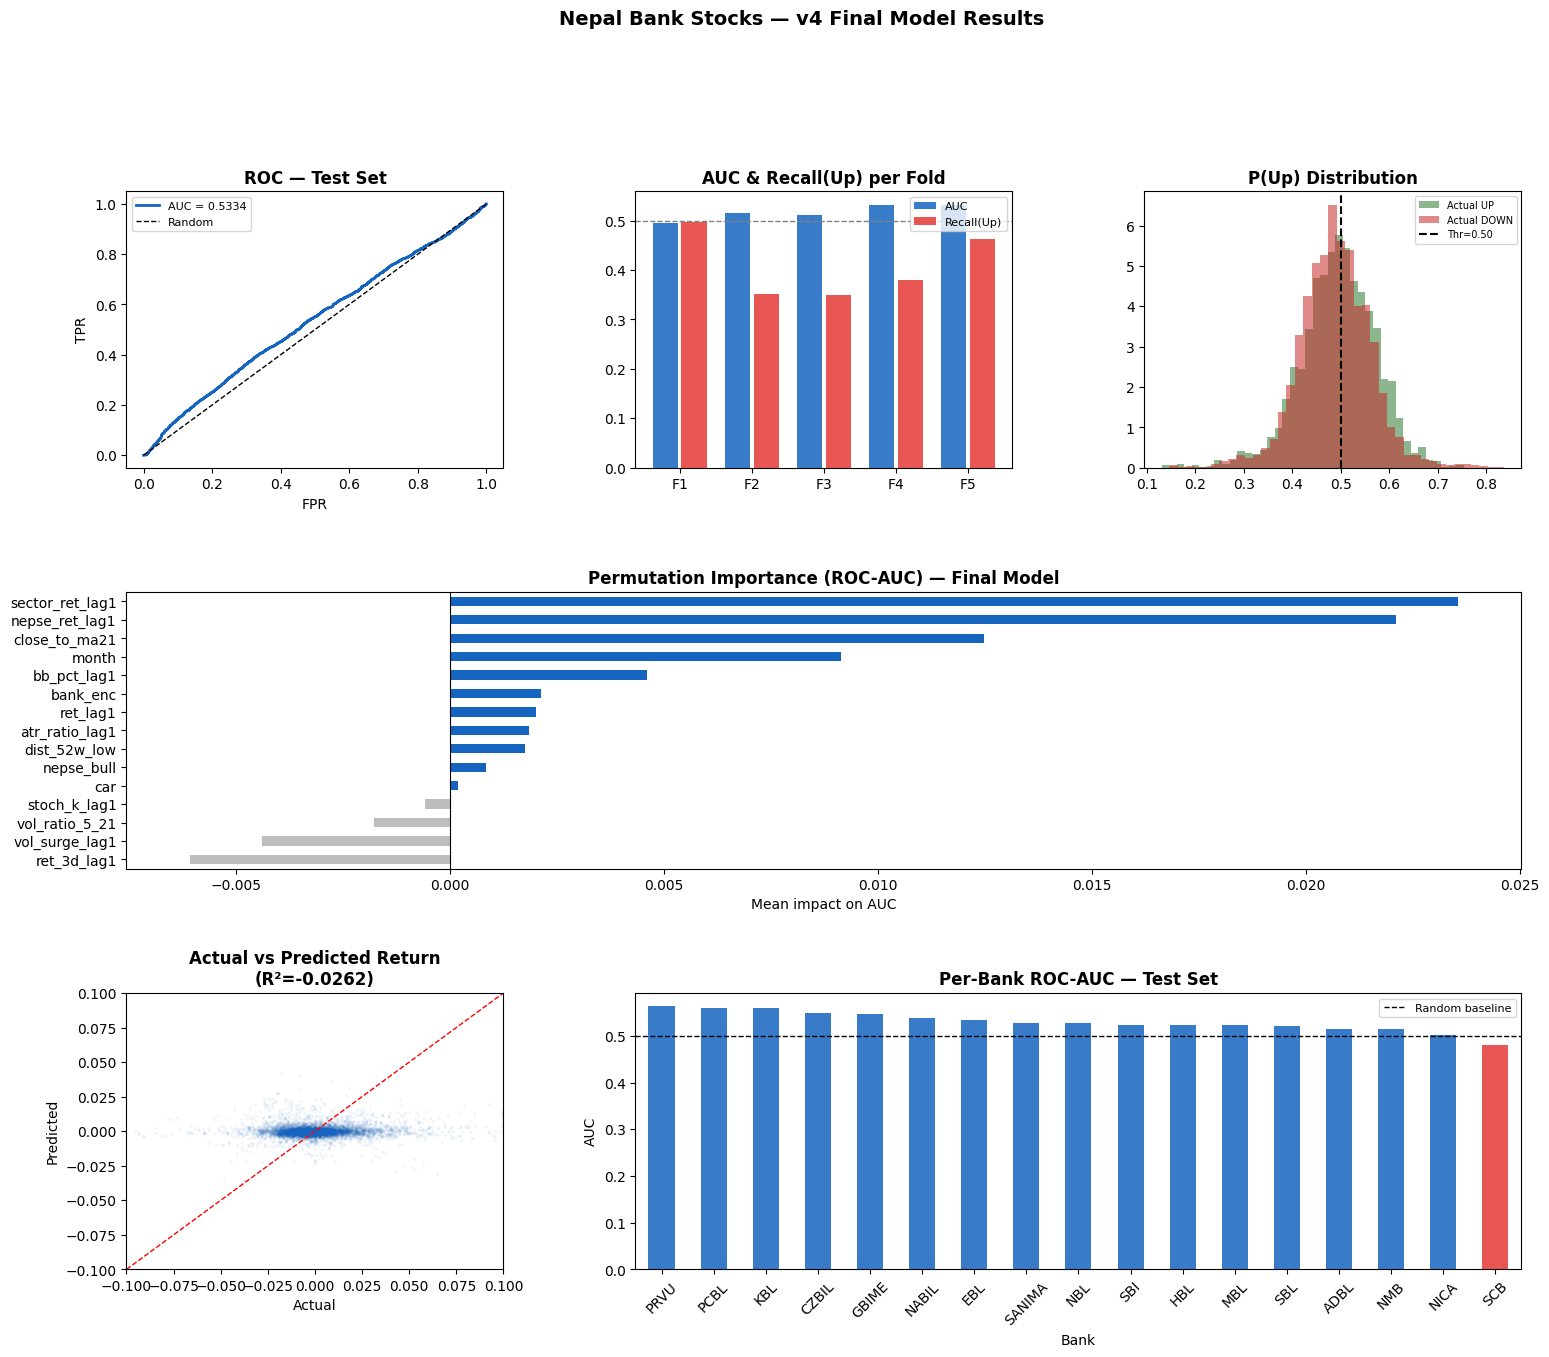

Plot saved → bank_v4_results.png


In [7]:
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── (A) ROC Curve ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_cls_test, prob_test)
auc_final   = roc_auc_score(y_cls_test, prob_test)
ax1.plot(fpr, tpr, color='#1565C0', lw=2, label=f'AUC = {auc_final:.4f}')
ax1.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax1.set_title('ROC — Test Set', fontweight='bold')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=8)

# ── (B) AUC per fold ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(fd))
ax2.bar(x-0.2, fd['auc'],    0.35, label='AUC',       color='#1565C0', alpha=0.85)
ax2.bar(x+0.2, fd['rec_up'], 0.35, label='Recall(Up)', color='#E53935', alpha=0.85)
ax2.axhline(0.5, color='gray', linestyle='--', lw=1)
ax2.set_xticks(x); ax2.set_xticklabels([f'F{i+1}' for i in x])
ax2.set_title('AUC & Recall(Up) per Fold', fontweight='bold')
ax2.legend(fontsize=8)

# ── (C) P(Up) distribution ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(prob_test[y_cls_test == 1], bins=40, alpha=0.55, density=True, color='#2E7D32', label='Actual UP')
ax3.hist(prob_test[y_cls_test == 0], bins=40, alpha=0.55, density=True, color='#C62828', label='Actual DOWN')
ax3.axvline(FINAL_THRESHOLD, color='black', lw=1.5, linestyle='--', label=f'Thr={FINAL_THRESHOLD:.2f}')
ax3.set_title('P(Up) Distribution', fontweight='bold')
ax3.legend(fontsize=7)

# ── (D) Feature importance ────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
print('Computing permutation importances ...')
idx = np.random.default_rng(42).choice(len(X_test), size=min(3000, len(X_test)), replace=False)
pi  = permutation_importance(
    final_cls, X_test.iloc[idx], y_cls_test.iloc[idx],
    n_repeats=15, random_state=42, scoring='roc_auc', n_jobs=-1
)
imp = pd.Series(pi.importances_mean, index=FEATURE_COLS).sort_values()
colors = ['#1565C0' if v > 0 else '#BDBDBD' for v in imp]
imp.plot(kind='barh', ax=ax4, color=colors)
ax4.axvline(0, color='black', lw=0.8)
ax4.set_title('Permutation Importance (ROC-AUC) — Final Model', fontweight='bold')
ax4.set_xlabel('Mean impact on AUC')

# ── (E) Actual vs Predicted return scatter ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.scatter(y_reg_test, pred_ret, alpha=0.04, s=2, color='#1565C0')
lim = 0.10
ax5.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax5.set_xlim(-lim, lim); ax5.set_ylim(-lim, lim)
ax5.set_title(f'Actual vs Predicted Return\n(R²={r2_score(y_reg_test, pred_ret):.4f})', fontweight='bold')
ax5.set_xlabel('Actual'); ax5.set_ylabel('Predicted')

# ── (F) Per-bank AUC bar ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1:])
test_df = feat_clean[test_mask].copy()
test_df['prob_up'] = prob_test
per_bank_auc = {}
for b in sorted(test_df['bank'].unique()):
    s = test_df[test_df['bank'] == b]
    try:
        per_bank_auc[b] = roc_auc_score(s['target_dir'], s['prob_up'])
    except Exception:
        per_bank_auc[b] = float('nan')
pba = pd.Series(per_bank_auc).sort_values(ascending=False)
bar_colors = ['#1565C0' if v >= 0.5 else '#E53935' for v in pba]
pba.plot(kind='bar', ax=ax6, color=bar_colors, alpha=0.85)
ax6.axhline(0.5, color='black', linestyle='--', lw=1, label='Random baseline')
ax6.set_title('Per-Bank ROC-AUC — Test Set', fontweight='bold')
ax6.set_xlabel('Bank'); ax6.set_ylabel('AUC')
ax6.tick_params(axis='x', rotation=45)
ax6.legend(fontsize=8)

plt.suptitle('Nepal Bank Stocks — v4 Final Model Results', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('bank_v4_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → bank_v4_results.png')